<a href="https://colab.research.google.com/github/karywnl/kaggle/blob/main/matplotlib_seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
from google.colab import drive

drive.mount("/content/drive")
os.environ["KAGGLE_CONFIG_DIR"] = "/content/drive/MyDrive/Kaggle"

!chmod 600 "/content/drive/MyDrive/Kaggle/kaggle.json"

Mounted at /content/drive


In [4]:
!kaggle datasets download -d 'alexisbcook/data-for-datavis'
!unzip data-for-datavis.zip

Dataset URL: https://www.kaggle.com/datasets/alexisbcook/data-for-datavis
License(s): unknown
  0% 0.00/142k [00:00<?, ?B/s]
100% 142k/142k [00:00<00:00, 374MB/s]
Archive:  data-for-datavis.zip
  inflating: cancer.csv              
  inflating: cancer_b.csv            
  inflating: cancer_m.csv            
  inflating: candy.csv               
  inflating: fifa.csv                
  inflating: flight_delays.csv       
  inflating: ign_scores.csv          
  inflating: insurance.csv           
  inflating: iris.csv                
  inflating: iris_setosa.csv         
  inflating: iris_versicolor.csv     
  inflating: iris_virginica.csv      
  inflating: museum_visitors.csv     
  inflating: spotify.csv             


In [5]:
fifa_data = pd.read_csv('fifa.csv')
fifa_data.head()

,Date,ARG,BRA,ESP,FRA,GER,ITA
0,1993-08-08,5.0,8.0,13.0,12.0,1.0,2.0
1,1993-09-23,12.0,1.0,14.0,7.0,5.0,2.0
2,1993-10-22,9.0,1.0,7.0,14.0,4.0,3.0
3,1993-11-19,9.0,4.0,7.0,15.0,3.0,1.0
4,1993-12-23,8.0,3.0,5.0,15.0,1.0,2.0


In [6]:
spotify_data = pd.read_csv("spotify.csv")

In [7]:
spotify_data.head()

,Date,Shape of You,Despacito,Something Just Like This,HUMBLE.,Unforgettable
0,2017-01-06,12287078,NaN,NaN,NaN,NaN
1,2017-01-07,13190270,NaN,NaN,NaN,NaN
2,2017-01-08,13099919,NaN,NaN,NaN,NaN
3,2017-01-09,14506351,NaN,NaN,NaN,NaN
4,2017-01-10,14275628,NaN,NaN,NaN,NaN


Line Plot in seaborn is more abstract it by default does everything unless you specifically asked to customize.

<Axes: >

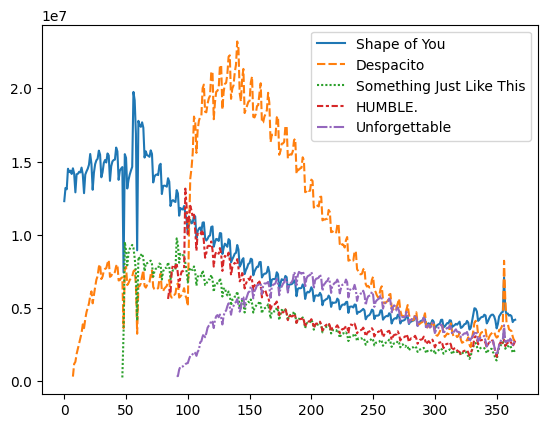

In [8]:
sns.lineplot(data=spotify_data)

In [9]:
museum_data = pd.read_csv("museum_visitors.csv", index_col="Date", parse_dates=True)
museum_data.head()

,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center
Date,,,,
2014-01-01,24778,4486,1581,6602
2014-02-01,18976,4172,1785,5029
2014-03-01,25231,7082,3229,8129
2014-04-01,26989,6756,2129,2824
2014-05-01,36883,10858,3676,10694


In [10]:
museum_data[museum_data.index == "2018-07-01"]["Chinese American Museum"].iloc[0]

np.int64(2620)

In [11]:
museum_data[museum_data.index == "2018-08-01"]["Avila Adobe"].iloc[0] - museum_data[museum_data.index == "2018-08-01"]["Firehouse Museum"].iloc[0]

np.int64(15949)

# **Bar charts and Heatmaps**

In [12]:
ign_data = pd.read_csv("ign_scores.csv", index_col="Platform")
ign_data.head()

,Action,"Action, Adventure",Adventure,Fighting,Platformer,Puzzle,RPG,Racing,Shooter,Simulation,Sports,Strategy
Platform,,,,,,,,,,,,
Dreamcast,6.882857,7.511111,6.281818,8.200000,8.340000,8.088889,7.700000,7.042500,7.616667,7.628571,7.272222,6.433333
Game Boy Advance,6.373077,7.507692,6.057143,6.226316,6.970588,6.532143,7.542857,6.657143,6.444444,6.928571,6.694444,7.175000
Game Boy Color,6.272727,8.166667,5.307692,4.500000,6.352941,6.583333,7.285714,5.897436,4.500000,5.900000,5.790698,7.400000
GameCube,6.532584,7.608333,6.753846,7.422222,6.665714,6.133333,7.890909,6.852632,6.981818,8.028571,7.481319,7.116667
Nintendo 3DS,6.670833,7.481818,7.414286,6.614286,7.503448,8.000000,7.719231,6.900000,7.033333,7.700000,6.388889,7.900000


In [13]:
ign_data.index

Index(['Dreamcast', 'Game Boy Advance', 'Game Boy Color', 'GameCube',
       'Nintendo 3DS', 'Nintendo 64', 'Nintendo DS', 'Nintendo DSi', 'PC',
       'PlayStation', 'PlayStation 2', 'PlayStation 3', 'PlayStation 4',
       'PlayStation Portable', 'PlayStation Vita', 'Wii', 'Wireless', 'Xbox',
       'Xbox 360', 'Xbox One', 'iPhone'],
      dtype='object', name='Platform')

1. What is the highest average score received by PC games for any genre?

In [14]:
ign_data.loc["PC"].max()

7.759930313588847

On the Playstation Vita platform, which genre has the lowest average score? Please provide the name of the column, and put your answer in single quotes (e.g., 'Action', 'Adventure', 'Fighting', etc.)

In [15]:
ign_data.loc["PlayStation Vita"].idxmin()

'Simulation'

Create a bar chart that shows the average score for racing games, for each platform. Your chart should have one bar for each platform.

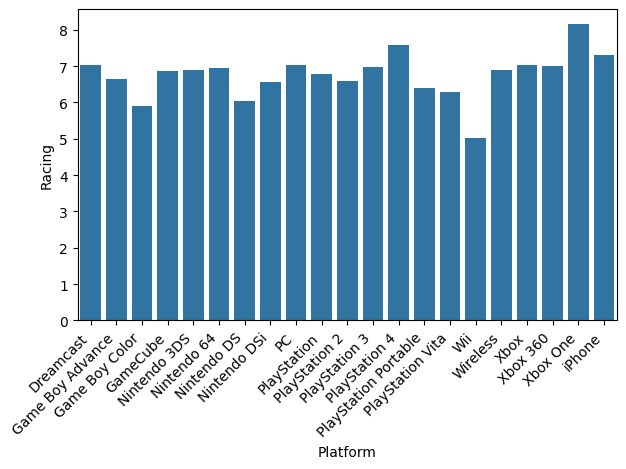

In [16]:
sns.barplot(x=ign_data.index, y=ign_data["Racing"])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


Use the data to create a heatmap of average score by genre and platform.

<Axes: ylabel='Platform'>

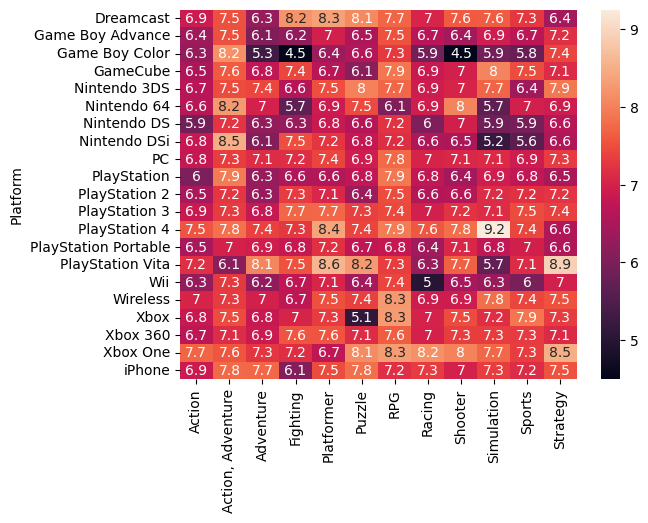

In [17]:
sns.heatmap(data=ign_data, annot=True)

# **Scatter Plots**

In [18]:
candy_data = pd.read_csv("candy.csv", index_col="id")
candy_data.head()

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
id,,,,,,,,,,,,,
0,100 Grand,Yes,No,Yes,No,No,Yes,No,Yes,No,0.732,0.860,66.971725
1,3 Musketeers,Yes,No,No,No,Yes,No,No,Yes,No,0.604,0.511,67.602936
2,Air Heads,No,Yes,No,No,No,No,No,No,No,0.906,0.511,52.341465
3,Almond Joy,Yes,No,No,Yes,No,No,No,Yes,No,0.465,0.767,50.347546
4,Baby Ruth,Yes,No,Yes,Yes,Yes,No,No,Yes,No,0.604,0.767,56.914547


In [19]:
candy_data.sort_values(by="winpercent", ascending=False)

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
id,,,,,,,,,,,,,
50,Reese's Peanut Butter cup,Yes,No,No,Yes,No,No,No,No,No,0.720,0.651,84.180290
49,Reese's Miniatures,Yes,No,No,Yes,No,No,No,No,No,0.034,0.279,81.866257
77,Twix,Yes,No,Yes,No,No,Yes,No,Yes,No,0.546,0.906,81.642914
26,Kit Kat,Yes,No,No,No,No,Yes,No,Yes,No,0.313,0.511,76.768600
62,Snickers,Yes,No,Yes,Yes,Yes,No,No,Yes,No,0.546,0.651,76.673782
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24,Jawbusters,No,Yes,No,No,No,No,Yes,No,Yes,0.093,0.511,28.127439
70,Super Bubble,No,Yes,No,No,No,No,No,No,No,0.162,0.116,27.303865
10,Chiclets,No,Yes,No,No,No,No,No,No,Yes,0.046,0.325,24.524988


Which candy was more popular with survey respondents '3 Musketeers' or 'Almond Joy'

In [20]:
candy_data.loc[candy_data[
    ((candy_data["competitorname"] == "3 Musketeers") | (candy_data["competitorname"] == "Almond Joy"))
].loc[: , 'winpercent'].idxmax()].loc["competitorname"]

'3 Musketeers'

 Which candy has higher sugar content: 'Air Heads' or 'Baby Ruth'?

In [21]:
candy_data.loc[candy_data[
    ((candy_data['competitorname'] == 'Air Heads') | (candy_data['competitorname'] == 'Almond Joy'))
].loc[: , 'sugarpercent'].idxmax()].loc["competitorname"]

'Air Heads'

.set_index() alternative - Easy lookup, hence O(1) approach

In [22]:
candy_data.set_index("competitorname").loc[["Air Heads", "Almond Joy"], "sugarpercent"].idxmax()

'Air Heads'

For better code quality you can create a seperate subset variable, for reusablity of the competitorname index.

In [23]:
subset = candy_data.set_index("competitorname")

subset.loc[["Air Heads", "Almond Joy"], "sugarpercent"].idxmax()

'Air Heads'

Create a scatter plot that shows the relationship between 'sugarpercent' (on the horizontal x-axis) and 'winpercent' (on the vertical y-axis)

<Axes: xlabel='sugarpercent', ylabel='winpercent'>

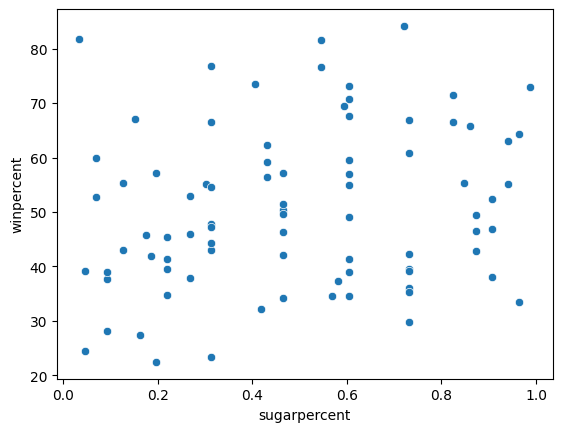

In [24]:
sns.scatterplot(x=candy_data["sugarpercent"], y=candy_data["winpercent"])

Scatter plot w/ regression line showing the relationship between 'sugarpercent' and 'winpercent'

<Axes: xlabel='sugarpercent', ylabel='winpercent'>

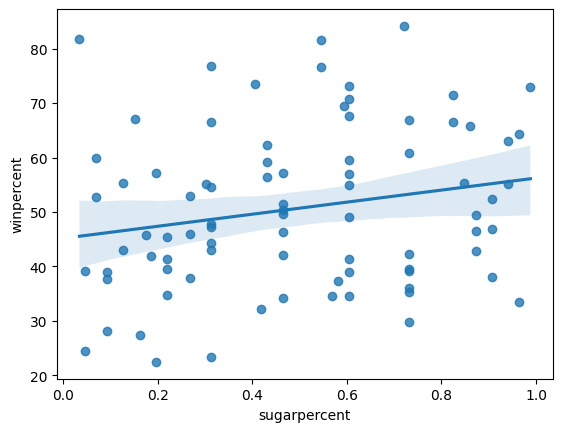

In [25]:
sns.regplot(x=candy_data["sugarpercent"], y=candy_data["winpercent"])

The regression line gives you a clean visual stand of the correlation between the variables. Its makes the interpretation easier. Like in the above case with the regression line we would say no relation, But looking at the regressoin line you can see there is slight positive relationship.

Scatter plot showing the relationship between 'pricepercent', 'winpercent', and 'chocolate'

<Axes: xlabel='pricepercent', ylabel='winpercent'>

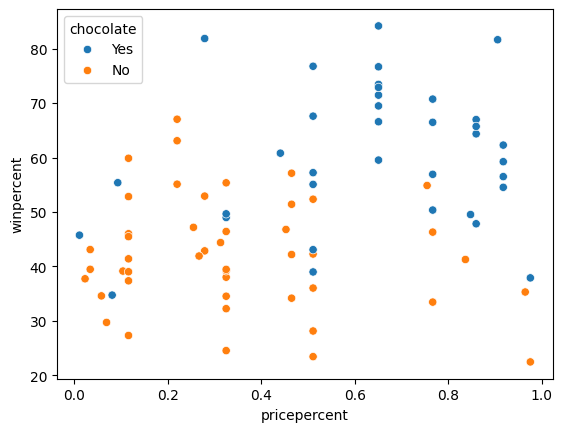

In [26]:
sns.scatterplot(x=candy_data["pricepercent"], y=candy_data["winpercent"], hue=candy_data["chocolate"])

Color-coded scatter plot w/ regression lines

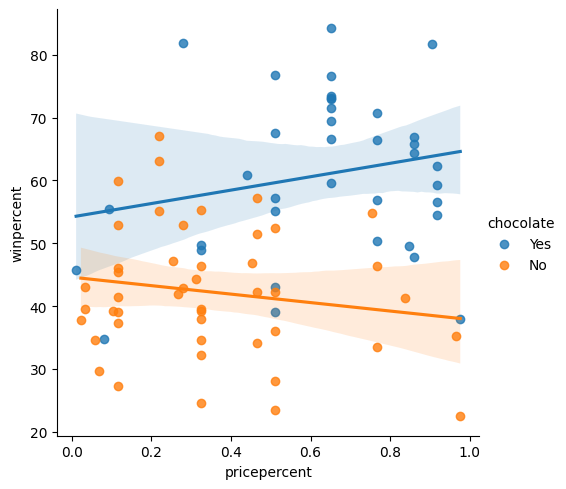

In [27]:
sns.lmplot(data=candy_data, x="pricepercent", y="winpercent", hue="chocolate")

Create a categorical scatter plot to highlight the relationship between 'chocolate' and 'winpercent'. Put 'chocolate' on the (horizontal) x-axis, and 'winpercent' on the (vertical) y-axis.

<Axes: xlabel='chocolate', ylabel='winpercent'>

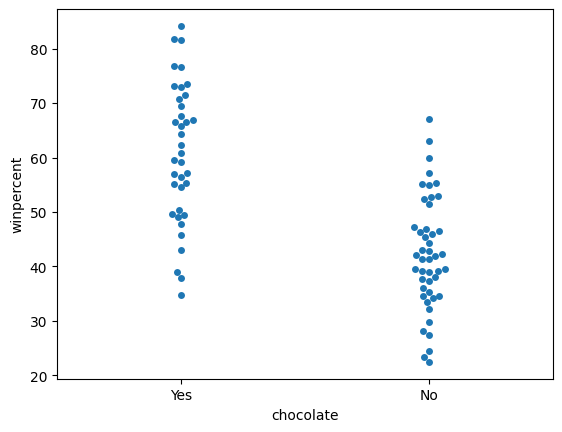

In [28]:
sns.swarmplot(x=candy_data["chocolate"], y=candy_data["winpercent"])

Sometimes, we need to work with categorical data, that way a scatter plot wouldn't be benificial, Because they form a single line for every categorical value. That's why we need some categorical plots, such as swarm plots - They spread horizontally when we have multiple datapoints at that particular y-value.

When multiple candies share a similar (but not identical) winpercent value, the algorithm has to decide where to place them. For example:

Candy A: winpercent = 54.1
Candy B: winpercent = 54.4
Candy C: winpercent = 54.8

These aren't the same y-value, but they're close enough that they'd collide if plotted normally. So the swarmplot algorithm:

*   Looks at a small neighborhood of y-values
*   Groups points that are close but not identical
*   Spreads them horizontally to avoid overlap

# **Distribution**

In [29]:
iris_data = pd.read_csv("iris.csv")
iris_data.head()

,Id,Sepal Length (cm),Sepal Width (cm),Petal Length (cm),Petal Width (cm),Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [30]:
cancer_data = pd.read_csv("cancer.csv", index_col="Id")
cancer_data.head()

,Diagnosis,Radius (mean),Texture (mean),Perimeter (mean),Area (mean),Smoothness (mean),Compactness (mean),Concavity (mean),Concave points (mean),Symmetry (mean),...,Radius (worst),Texture (worst),Perimeter (worst),Area (worst),Smoothness (worst),Compactness (worst),Concavity (worst),Concave points (worst),Symmetry (worst),Fractal dimension (worst)
Id,,,,,,,,,,,,,,,,,,,,,
8510426,B,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,15.110,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259
8510653,B,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,14.500,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183
8510824,B,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,10.230,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773
854941,B,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,13.300,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169
85713702,B,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,8.964,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409


In the first five rows of the data, what is the largest value for 'Perimeter (mean)'

In [31]:
cancer_data.head()["Perimeter (mean)"].max()

87.46

What is the value for 'Radius (mean)' for the tumor with Id 8510824

In [32]:
cancer_data["Radius (mean)"].loc[8510824]

np.float64(9.504)

# **Subplots**

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

This creates 1 row and 2 columns, like this

|   axes[0]   |   axes[1]   |


<Axes: xlabel='Area (mean)', ylabel='Count'>

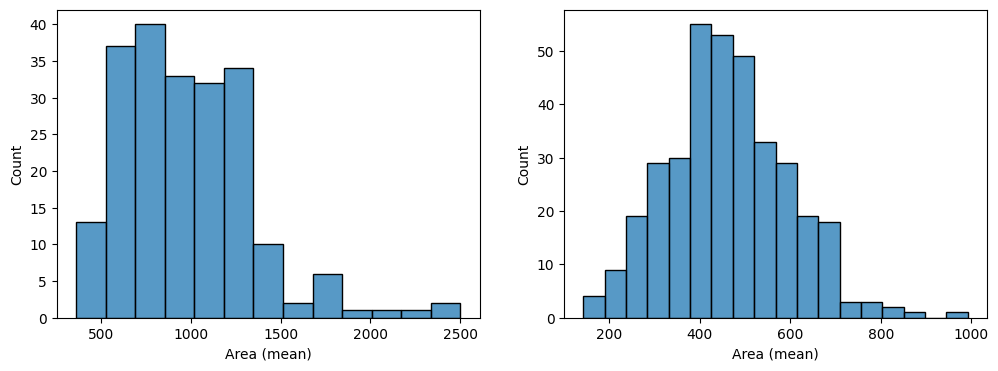

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=cancer_data[cancer_data["Diagnosis"] == "M"], x="Area (mean)", ax=axes[0])
sns.histplot(data=cancer_data[cancer_data["Diagnosis"] == "B"], x="Area (mean)", ax=axes[1])

<Axes: xlabel='Area (mean)', ylabel='Count'>

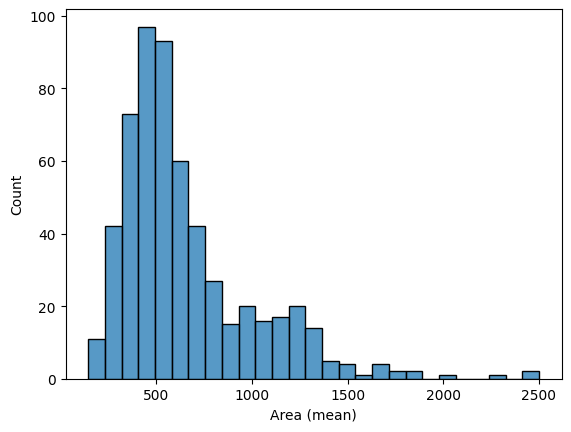

In [34]:
sns.histplot(data=cancer_data, x="Area (mean)")

<Axes: xlabel='Area (mean)', ylabel='Count'>

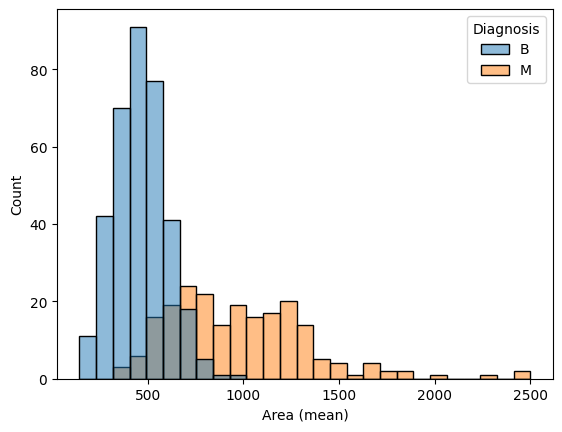

In [35]:
sns.histplot(data=cancer_data, x="Area (mean)", hue="Diagnosis")

<Axes: xlabel='Radius (worst)', ylabel='Density'>

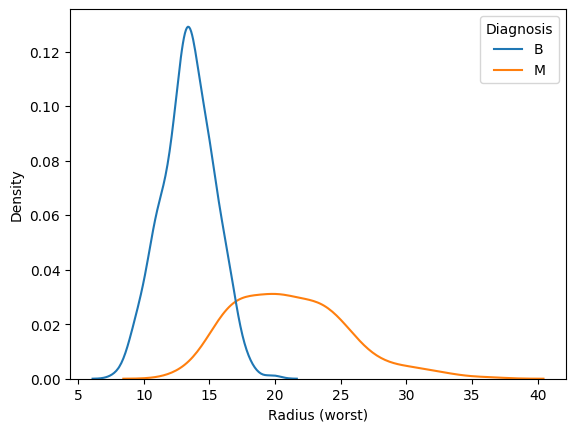

In [36]:
sns.kdeplot(data=cancer_data, x="Radius (worst)", hue="Diagnosis")

# **What to choose and when to choose ?**

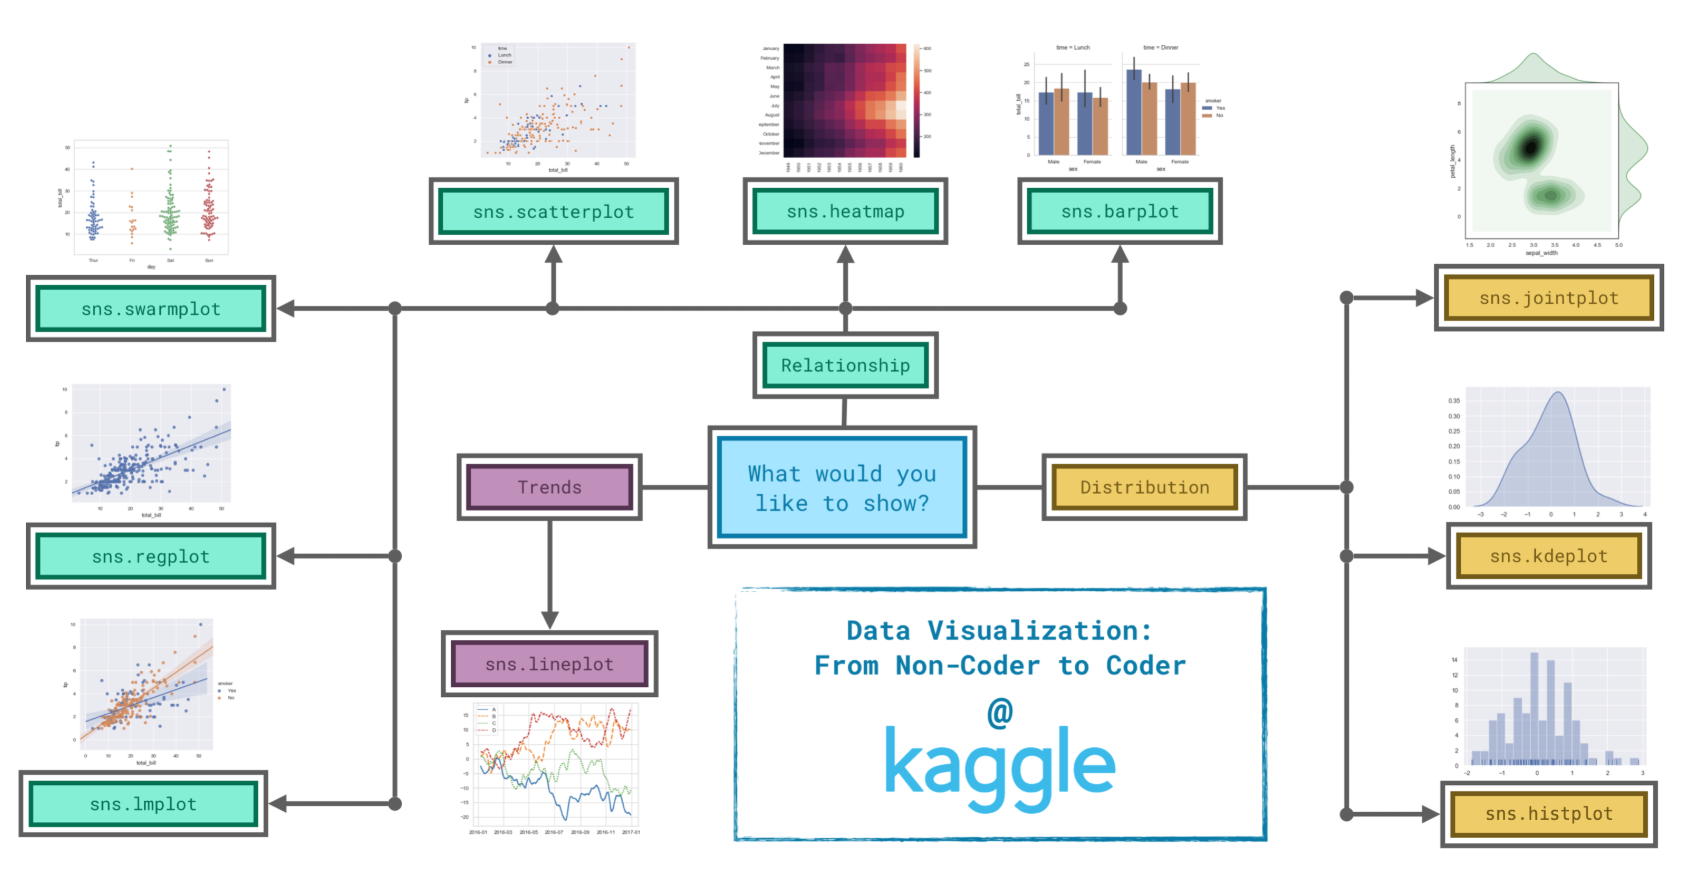